<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Magic_Numbers_Response_Closure_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Magic Numbers as Response-Closure Minima — Evidence Notebook V1

This notebook tests whether nuclear magic numbers emerge as enhanced response-closure discontinuities in AME2020 data.

**Target magic numbers:**

\[2, 8, 20, 28, 50, 82, 126\]

The notebook loads `ame2020.csv`, computes total binding energy, neutron/proton separation energies, two-nucleon separation energies, and shell-gap diagnostics:

\[
\delta_{2n}(N,Z)=S_{2n}(N,Z)-S_{2n}(N+2,Z)
\]

\[
\delta_{2p}(N,Z)=S_{2p}(N,Z)-S_{2p}(N,Z+2)
\]

In the ECSM interpretation, large positive shell gaps are treated as candidate finite-response closure jumps: adding particles beyond a closure layer requires a larger response reconfiguration cost.

This is a first evidence notebook, not a first-principles shell model.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# CELL 01 — SETUP

import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

OUT = Path('ecsm_magic_numbers_response_closure_v1_out')
FIG = OUT / 'figures'
TAB = OUT / 'tables'
DATA = OUT / 'data'
for p in [OUT, FIG, TAB, DATA]:
    p.mkdir(parents=True, exist_ok=True)

MAGIC = [2, 8, 20, 28, 50, 82, 126]
print('Output directory:', OUT)
print('Magic numbers:', MAGIC)


Output directory: ecsm_magic_numbers_response_closure_v1_out
Magic numbers: [2, 8, 20, 28, 50, 82, 126]


## Load AME2020 CSV

The expected Colab path is:

`/content/drive/MyDrive/ame2020.csv`

If running locally, place `ame2020.csv` in the working directory or edit `AME_CSV_PATH` below.


In [3]:
# CELL 02 — LOAD AME2020 CSV

AME_CSV_PATH = Path('/content/drive/MyDrive/ame2020.csv')
if not AME_CSV_PATH.exists():
    fallback = Path('ame2020.csv')
    if fallback.exists():
        AME_CSV_PATH = fallback

if not AME_CSV_PATH.exists():
    raise FileNotFoundError('Could not find ame2020.csv. Put it at /content/drive/MyDrive/ame2020.csv or in the current folder.')

ame = pd.read_csv(AME_CSV_PATH)
print('Loaded:', AME_CSV_PATH)
print('Shape:', ame.shape)
print('Columns:', list(ame.columns)[:20], '...')
display(ame.head())


Loaded: /content/drive/MyDrive/ame2020.csv
Shape: (3378, 104)
Columns: ['nucid', 'n', 'z', 'mass_excess', 'mass_excess_num', 'mass_excess_unc', 'mass_excess_sys', 'mass_excess_round', 'mass_excess_round_unc', 'binding', 'binding_num', 'binding_unc', 'binding_sys', 'binding_round', 'binding_round_unc', 'beta_decay_en_round', 'beta_decay_en_round_unc', 'beta_decay_en', 'beta_decay_en_num', 'beta_decay_en_unc'] ...


,nucid,n,z,mass_excess,mass_excess_num,mass_excess_unc,mass_excess_sys,mass_excess_round,mass_excess_round_unc,binding,...,qna_num,qna_unc,qna_round,qna_round_unc,qna_sys,qec_num,qec_unc,qec_round,qec_round_unc,qec
0,1N,1,0,8071.318060,8071.318060,0.000440,N,8071.31810,0.00040,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1H,0,1,7288.971064,7288.971064,0.000013,N,7288.97106,0.00001,0.00000,...,NaN,NaN,NaN,NaN,NaN,-782.347,0.0,-782.347,0.0,-782.347
2,2H,1,1,13135.722895,13135.722895,0.000015,N,13135.72290,0.00002,1112.28310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3H,2,1,14949.810900,14949.810900,0.000080,N,14949.81090,0.00008,2827.26540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3HE,1,2,14931.218880,14931.218880,0.000060,N,14931.21888,0.00006,2572.68044,...,NaN,NaN,20577.6189,0.0005,NaN,-18.592,0.0,-18.592,0.0,-18.592


In [4]:
# CELL 03 — STANDARDISE COLUMNS AND COMPUTE TOTAL BINDING

work = ame.copy()
work['N'] = pd.to_numeric(work['n'], errors='coerce')
work['Z'] = pd.to_numeric(work['z'], errors='coerce')
work['A'] = work['N'] + work['Z']
work['BE_per_A_keV'] = pd.to_numeric(work['binding'], errors='coerce')
work['BE_per_A_MeV'] = work['BE_per_A_keV'] / 1000.0
work['BE_total_MeV'] = work['BE_per_A_MeV'] * work['A']

work = work.dropna(subset=['A','N','Z','BE_per_A_MeV','BE_total_MeV']).copy()
work[['A','N','Z']] = work[['A','N','Z']].astype(int)
work = work[work['A'] >= 1].copy()

summary = {
    'data_source': str(AME_CSV_PATH),
    'n_rows': int(len(work)),
    'A_min': int(work['A'].min()),
    'A_max': int(work['A'].max()),
    'Z_min': int(work['Z'].min()),
    'Z_max': int(work['Z'].max()),
    'N_min': int(work['N'].min()),
    'N_max': int(work['N'].max()),
    'BEA_min_MeV': float(work['BE_per_A_MeV'].min()),
    'BEA_max_MeV': float(work['BE_per_A_MeV'].max()),
}
print(json.dumps(summary, indent=2))
with open(OUT/'dataset_summary.json','w') as f:
    json.dump(summary, f, indent=2)

display(work[['nucid','A','Z','N','BE_per_A_MeV','BE_total_MeV']].head(15))


{
  "data_source": "/content/drive/MyDrive/ame2020.csv",
  "n_rows": 3378,
  "A_min": 1,
  "A_max": 295,
  "Z_min": 0,
  "Z_max": 118,
  "N_min": 0,
  "N_max": 177,
  "BEA_min_MeV": -2.267,
  "BEA_max_MeV": 8.7945555
}


,nucid,A,Z,N,BE_per_A_MeV,BE_total_MeV
0,1N,1,0,1,0.000000,0.000000
1,1H,1,1,0,0.000000,0.000000
2,2H,2,1,1,1.112283,2.224566
3,3H,3,1,2,2.827265,8.481796
4,3HE,3,2,1,2.572680,7.718041
5,3LI,3,3,0,-2.267000,-6.801000
6,4H,4,1,3,1.720449,6.881796
7,4HE,4,2,2,7.073916,28.295662
8,4LI,4,3,1,1.153760,4.615041
9,5H,5,1,4,1.336359,6.681796


## Separation energies and shell gaps

For a nucleus \((N,Z)\) with total binding energy \(B(N,Z)\):

\[
S_n(N,Z)=B(N,Z)-B(N-1,Z)
\]

\[
S_{2n}(N,Z)=B(N,Z)-B(N-2,Z)
\]

\[
S_p(N,Z)=B(N,Z)-B(N,Z-1)
\]

\[
S_{2p}(N,Z)=B(N,Z)-B(N,Z-2)
\]

The two-neutron and two-proton shell gaps are then computed as local discontinuities:

\[
\delta_{2n}(N,Z)=S_{2n}(N,Z)-S_{2n}(N+2,Z)
\]

\[
\delta_{2p}(N,Z)=S_{2p}(N,Z)-S_{2p}(N,Z+2).
\]


In [5]:
# CELL 04 — COMPUTE SEPARATION ENERGIES AND SHELL GAPS

be = {(int(r.N), int(r.Z)): float(r.BE_total_MeV) for r in work.itertuples(index=False)}

Sn, S2n, Sp, S2p = [], [], [], []
for r in work.itertuples(index=False):
    N, Z, B = int(r.N), int(r.Z), float(r.BE_total_MeV)
    Sn.append(B - be[(N-1, Z)] if (N-1, Z) in be else np.nan)
    S2n.append(B - be[(N-2, Z)] if (N-2, Z) in be else np.nan)
    Sp.append(B - be[(N, Z-1)] if (N, Z-1) in be else np.nan)
    S2p.append(B - be[(N, Z-2)] if (N, Z-2) in be else np.nan)

work['Sn_MeV'] = Sn
work['S2n_MeV'] = S2n
work['Sp_MeV'] = Sp
work['S2p_MeV'] = S2p

# Shell gaps: value at closure compared with two particles beyond closure
s2n_map = {(int(r.N), int(r.Z)): float(r.S2n_MeV) for r in work.dropna(subset=['S2n_MeV']).itertuples(index=False)}
s2p_map = {(int(r.N), int(r.Z)): float(r.S2p_MeV) for r in work.dropna(subset=['S2p_MeV']).itertuples(index=False)}

d2n, d2p = [], []
for r in work.itertuples(index=False):
    N, Z = int(r.N), int(r.Z)
    d2n.append(s2n_map[(N,Z)] - s2n_map[(N+2,Z)] if (N,Z) in s2n_map and (N+2,Z) in s2n_map else np.nan)
    d2p.append(s2p_map[(N,Z)] - s2p_map[(N,Z+2)] if (N,Z) in s2p_map and (N,Z+2) in s2p_map else np.nan)

work['delta2n_MeV'] = d2n
work['delta2p_MeV'] = d2p
work['is_magic_N'] = work['N'].isin(MAGIC)
work['is_magic_Z'] = work['Z'].isin(MAGIC)

work.to_csv(TAB/'ame2020_with_separation_and_shell_gaps.csv', index=False)
print('Saved:', TAB/'ame2020_with_separation_and_shell_gaps.csv')
display(work[['nucid','A','Z','N','BE_per_A_MeV','Sn_MeV','S2n_MeV','delta2n_MeV','Sp_MeV','S2p_MeV','delta2p_MeV']].head(20))


Saved: ecsm_magic_numbers_response_closure_v1_out/tables/ame2020_with_separation_and_shell_gaps.csv


,nucid,A,Z,N,BE_per_A_MeV,Sn_MeV,S2n_MeV,delta2n_MeV,Sp_MeV,S2p_MeV,delta2p_MeV
0,1N,1,0,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,1H,1,1,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,2H,2,1,1,1.112283,2.224566,NaN,NaN,2.224566,NaN,NaN
3,3H,3,1,2,2.827265,6.257230,8.481796,10.281796,NaN,NaN,NaN
4,3HE,3,2,1,2.572680,NaN,NaN,NaN,5.493475,7.718041,15.346083
5,3LI,3,3,0,-2.267000,NaN,NaN,NaN,NaN,-6.801000,NaN
6,4H,4,1,3,1.720449,-1.600000,4.657230,5.769190,NaN,NaN,NaN
7,4HE,4,2,2,7.073916,20.577621,NaN,NaN,19.813866,NaN,NaN
8,4LI,4,3,1,1.153760,11.416041,NaN,NaN,-3.103000,2.390475,9.807516
9,5H,5,1,4,1.336359,-0.200000,-1.800000,-1.698204,NaN,NaN,NaN


In [6]:
# CELL 05 — MAGIC VS NON-MAGIC SHELL-GAP STATISTICS

def gap_stats(df, gap_col, magic_col, label):
    x_magic = df.loc[df[magic_col], gap_col].dropna()
    x_non = df.loc[~df[magic_col], gap_col].dropna()
    return {
        'channel': label,
        'n_magic': int(len(x_magic)),
        'n_nonmagic': int(len(x_non)),
        'magic_mean_MeV': float(x_magic.mean()),
        'nonmagic_mean_MeV': float(x_non.mean()),
        'magic_median_MeV': float(x_magic.median()),
        'nonmagic_median_MeV': float(x_non.median()),
        'mean_lift_MeV': float(x_magic.mean() - x_non.mean()),
        'median_lift_MeV': float(x_magic.median() - x_non.median()),
        'magic_fraction_positive': float((x_magic > 0).mean()),
        'nonmagic_fraction_positive': float((x_non > 0).mean()),
    }

stats = pd.DataFrame([
    gap_stats(work, 'delta2n_MeV', 'is_magic_N', 'neutron_magic_N_delta2n'),
    gap_stats(work, 'delta2p_MeV', 'is_magic_Z', 'proton_magic_Z_delta2p'),
])

stats.to_csv(TAB/'magic_vs_nonmagic_shell_gap_stats.csv', index=False)
print('Magic vs non-magic shell-gap statistics:')
display(stats)


Magic vs non-magic shell-gap statistics:


,channel,n_magic,n_nonmagic,magic_mean_MeV,nonmagic_mean_MeV,magic_median_MeV,nonmagic_median_MeV,mean_lift_MeV,median_lift_MeV,magic_fraction_positive,nonmagic_fraction_positive
0,neutron_magic_N_delta2n,107,2767,5.132887,1.246431,4.374078,0.762912,3.886456,3.611166,1.0,0.988435
1,proton_magic_Z_delta2p,130,2537,6.327694,2.931406,5.713669,2.324694,3.396287,3.388974,1.0,0.999212


In [7]:
# CELL 06 — PER-MAGIC-NUMBER SUMMARY

rows = []
for m in MAGIC:
    dn = work.loc[work['N'] == m, 'delta2n_MeV'].dropna()
    dp = work.loc[work['Z'] == m, 'delta2p_MeV'].dropna()
    rows.append({
        'magic_number': m,
        'n_delta2n_rows': int(len(dn)),
        'delta2n_mean_MeV': float(dn.mean()) if len(dn) else np.nan,
        'delta2n_median_MeV': float(dn.median()) if len(dn) else np.nan,
        'delta2n_max_MeV': float(dn.max()) if len(dn) else np.nan,
        'n_delta2p_rows': int(len(dp)),
        'delta2p_mean_MeV': float(dp.mean()) if len(dp) else np.nan,
        'delta2p_median_MeV': float(dp.median()) if len(dp) else np.nan,
        'delta2p_max_MeV': float(dp.max()) if len(dp) else np.nan,
    })

magic_summary = pd.DataFrame(rows)
magic_summary.to_csv(TAB/'per_magic_number_shell_gap_summary.csv', index=False)
display(magic_summary)


,magic_number,n_delta2n_rows,delta2n_mean_MeV,delta2n_median_MeV,delta2n_max_MeV,n_delta2p_rows,delta2p_mean_MeV,delta2p_median_MeV,delta2p_max_MeV
0,2,2,15.249520,15.249520,20.217244,1,15.346083,15.346083,15.346083
1,8,9,7.657156,6.675953,16.698968,12,11.609364,12.060751,17.811515
2,20,15,4.060157,4.158212,9.087006,20,7.095309,7.296228,10.475919
3,28,18,4.118452,4.553351,8.308110,27,6.345035,6.176360,9.261806
4,50,22,4.760932,4.987067,6.773974,35,6.073305,5.528468,9.441760
5,82,26,4.428989,4.148356,6.527122,35,4.061541,3.685206,6.598252
6,126,15,6.325116,3.476698,44.778880,0,NaN,NaN,NaN


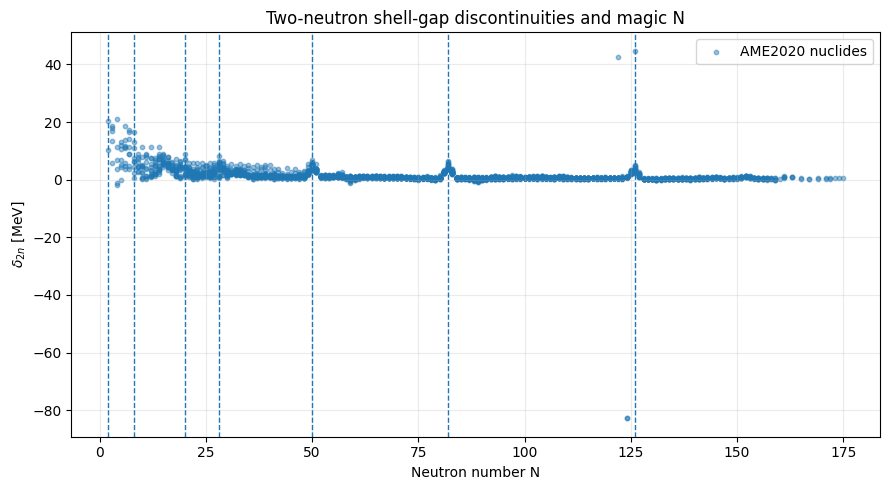

Saved: ecsm_magic_numbers_response_closure_v1_out/figures/fig01_delta2n_magic_N.png


In [8]:
# CELL 07 — FIGURE 1: TWO-NEUTRON SHELL GAPS VS N

fig, ax = plt.subplots(figsize=(9,5))
plot_df = work.dropna(subset=['delta2n_MeV']).copy()
ax.scatter(plot_df['N'], plot_df['delta2n_MeV'], s=10, alpha=0.45, label='AME2020 nuclides')
for m in MAGIC:
    ax.axvline(m, linestyle='--', linewidth=1)
ax.set_xlabel('Neutron number N')
ax.set_ylabel(r'$\delta_{2n}$ [MeV]')
ax.set_title('Two-neutron shell-gap discontinuities and magic N')
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG/'fig01_delta2n_magic_N.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG/'fig01_delta2n_magic_N.pdf', bbox_inches='tight')
plt.show()
print('Saved:', FIG/'fig01_delta2n_magic_N.png')


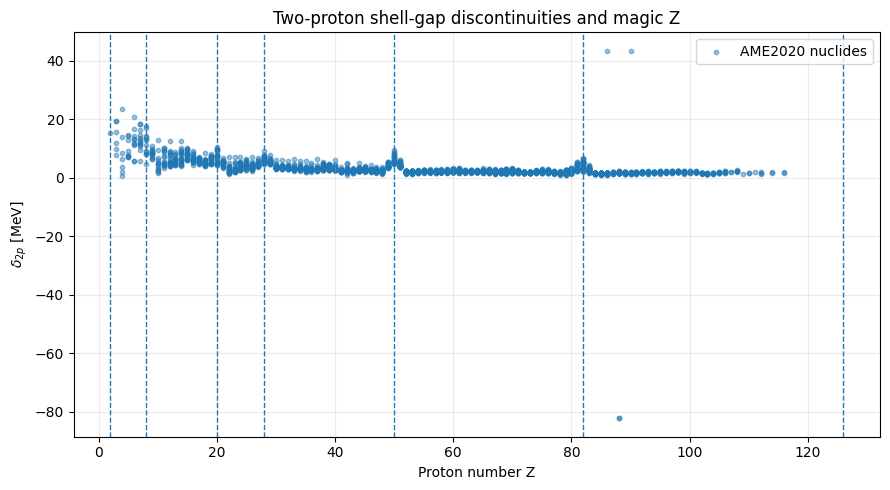

Saved: ecsm_magic_numbers_response_closure_v1_out/figures/fig02_delta2p_magic_Z.png


In [9]:
# CELL 08 — FIGURE 2: TWO-PROTON SHELL GAPS VS Z

fig, ax = plt.subplots(figsize=(9,5))
plot_df = work.dropna(subset=['delta2p_MeV']).copy()
ax.scatter(plot_df['Z'], plot_df['delta2p_MeV'], s=10, alpha=0.45, label='AME2020 nuclides')
for m in MAGIC:
    ax.axvline(m, linestyle='--', linewidth=1)
ax.set_xlabel('Proton number Z')
ax.set_ylabel(r'$\delta_{2p}$ [MeV]')
ax.set_title('Two-proton shell-gap discontinuities and magic Z')
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG/'fig02_delta2p_magic_Z.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG/'fig02_delta2p_magic_Z.pdf', bbox_inches='tight')
plt.show()
print('Saved:', FIG/'fig02_delta2p_magic_Z.png')


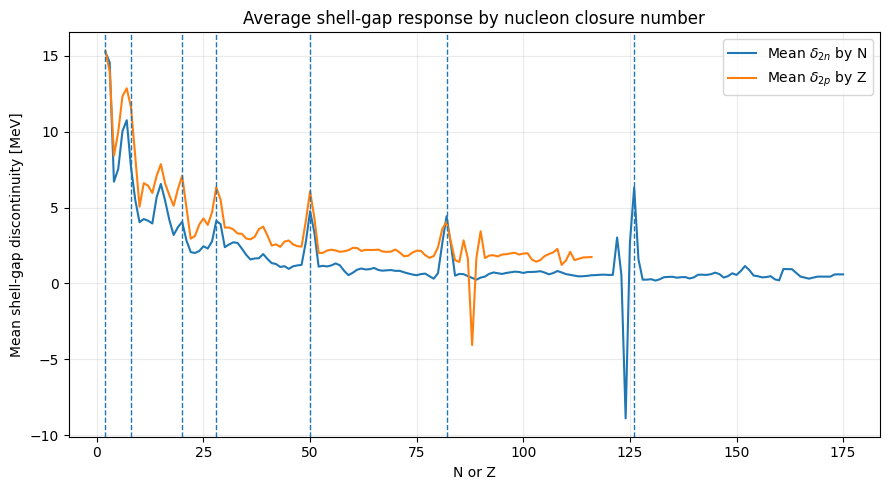

In [10]:
# CELL 09 — FIGURE 3: MEAN GAP BY N AND Z

n_profile = work.dropna(subset=['delta2n_MeV']).groupby('N', as_index=False)['delta2n_MeV'].mean()
z_profile = work.dropna(subset=['delta2p_MeV']).groupby('Z', as_index=False)['delta2p_MeV'].mean()
n_profile.to_csv(TAB/'mean_delta2n_by_N.csv', index=False)
z_profile.to_csv(TAB/'mean_delta2p_by_Z.csv', index=False)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(n_profile['N'], n_profile['delta2n_MeV'], label=r'Mean $\delta_{2n}$ by N')
ax.plot(z_profile['Z'], z_profile['delta2p_MeV'], label=r'Mean $\delta_{2p}$ by Z')
for m in MAGIC:
    ax.axvline(m, linestyle='--', linewidth=1)
ax.set_xlabel('N or Z')
ax.set_ylabel('Mean shell-gap discontinuity [MeV]')
ax.set_title('Average shell-gap response by nucleon closure number')
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG/'fig03_mean_shell_gap_profiles.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG/'fig03_mean_shell_gap_profiles.pdf', bbox_inches='tight')
plt.show()


## ECSM closure descriptors

This cell constructs simple closure descriptors centered on the standard magic numbers. The aim is not to fit a complete shell model, but to test whether a finite-response closure descriptor has predictive relationship to measured shell-gap discontinuities.


In [11]:
# CELL 10 — ECSM MAGIC CLOSURE DESCRIPTOR TEST

def gaussian_magic_distance(x, sigma=2.0):
    x = np.asarray(x, dtype=float)
    vals = np.zeros_like(x)
    for m in MAGIC:
        vals = np.maximum(vals, np.exp(-0.5*((x-m)/sigma)**2))
    return vals

work['closure_N_sigma2'] = gaussian_magic_distance(work['N'], sigma=2.0)
work['closure_Z_sigma2'] = gaussian_magic_distance(work['Z'], sigma=2.0)
work['closure_N_exact'] = work['N'].isin(MAGIC).astype(float)
work['closure_Z_exact'] = work['Z'].isin(MAGIC).astype(float)

# correlations between closure descriptor and shell-gap signal
corrs = []
for gap, desc, label in [
    ('delta2n_MeV','closure_N_sigma2','N gaussian closure vs delta2n'),
    ('delta2p_MeV','closure_Z_sigma2','Z gaussian closure vs delta2p'),
    ('delta2n_MeV','closure_N_exact','N exact magic vs delta2n'),
    ('delta2p_MeV','closure_Z_exact','Z exact magic vs delta2p'),
]:
    d = work[[gap, desc]].dropna()
    corrs.append({
        'test': label,
        'n': int(len(d)),
        'corr': float(np.corrcoef(d[gap], d[desc])[0,1]),
        'mean_gap_high_descriptor': float(d.loc[d[desc] >= 0.5, gap].mean()),
        'mean_gap_low_descriptor': float(d.loc[d[desc] < 0.5, gap].mean()),
        'mean_lift': float(d.loc[d[desc] >= 0.5, gap].mean() - d.loc[d[desc] < 0.5, gap].mean()),
    })

closure_tests = pd.DataFrame(corrs)
closure_tests.to_csv(TAB/'ecsm_magic_closure_descriptor_tests.csv', index=False)
display(closure_tests)


,test,n,corr,mean_gap_high_descriptor,mean_gap_low_descriptor,mean_lift
0,N gaussian closure vs delta2n,2874,0.293511,2.907790,1.032997,1.874793
1,Z gaussian closure vs delta2p,2667,0.319588,4.712853,2.578330,2.134522
2,N exact magic vs delta2n,2874,0.235970,5.132887,1.246431,3.886456
3,Z exact magic vs delta2p,2667,0.217043,6.327694,2.931406,3.396287


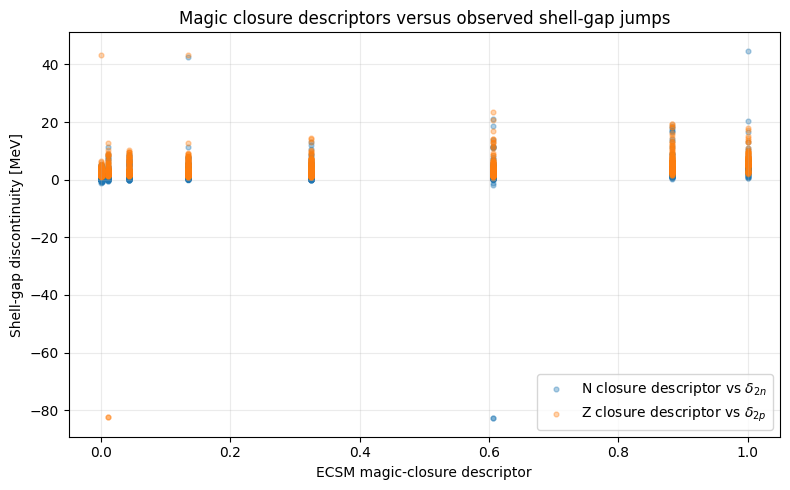

In [12]:
# CELL 11 — FIGURE 4: CLOSURE DESCRIPTOR VS GAP SIGNAL

fig, ax = plt.subplots(figsize=(8,5))
dn = work.dropna(subset=['delta2n_MeV','closure_N_sigma2'])
dp = work.dropna(subset=['delta2p_MeV','closure_Z_sigma2'])
ax.scatter(dn['closure_N_sigma2'], dn['delta2n_MeV'], s=12, alpha=0.35, label=r'N closure descriptor vs $\delta_{2n}$')
ax.scatter(dp['closure_Z_sigma2'], dp['delta2p_MeV'], s=12, alpha=0.35, label=r'Z closure descriptor vs $\delta_{2p}$')
ax.set_xlabel('ECSM magic-closure descriptor')
ax.set_ylabel('Shell-gap discontinuity [MeV]')
ax.set_title('Magic closure descriptors versus observed shell-gap jumps')
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG/'fig04_closure_descriptor_vs_gap.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG/'fig04_closure_descriptor_vs_gap.pdf', bbox_inches='tight')
plt.show()


In [13]:
# CELL 12 — RANKING TEST: DO MAGIC NUMBERS APPEAR AMONG LARGEST MEAN GAPS?

# Rank N and Z by mean shell gap
n_rank = n_profile.sort_values('delta2n_MeV', ascending=False).reset_index(drop=True)
z_rank = z_profile.sort_values('delta2p_MeV', ascending=False).reset_index(drop=True)
n_rank['rank'] = np.arange(1, len(n_rank)+1)
z_rank['rank'] = np.arange(1, len(z_rank)+1)
n_rank['is_magic'] = n_rank['N'].isin(MAGIC)
z_rank['is_magic'] = z_rank['Z'].isin(MAGIC)

n_rank.to_csv(TAB/'ranked_mean_delta2n_by_N.csv', index=False)
z_rank.to_csv(TAB/'ranked_mean_delta2p_by_Z.csv', index=False)

def topk_magic_fraction(rank_df, col, ks=[10,20,30,50]):
    out=[]
    for k in ks:
        top = rank_df.head(k)
        out.append({'top_k': k, 'magic_count': int(top['is_magic'].sum()), 'magic_values': ','.join(map(str, top.loc[top['is_magic'], col].tolist()))})
    return out

ranking_summary = pd.DataFrame(
    [{'channel':'N_delta2n', **x} for x in topk_magic_fraction(n_rank, 'N')] +
    [{'channel':'Z_delta2p', **x} for x in topk_magic_fraction(z_rank, 'Z')]
)
ranking_summary.to_csv(TAB/'magic_number_ranking_summary.csv', index=False)

print('Top N by mean delta2n:')
display(n_rank.head(25))
print('Top Z by mean delta2p:')
display(z_rank.head(25))
print('Ranking summary:')
display(ranking_summary)


Top N by mean delta2n:


,N,delta2n_MeV,rank,is_magic
0,2,15.249520,1,True
1,3,14.575921,2,False
2,7,10.761948,3,False
3,6,10.042696,4,False
4,8,7.657156,5,True
5,5,7.542268,6,False
6,4,6.708196,7,False
7,15,6.561836,8,False
8,126,6.325116,9,True
9,14,5.664796,10,False


Top Z by mean delta2p:


,Z,delta2p_MeV,rank,is_magic
0,2,15.346083,1,True
1,3,13.978212,2,False
2,7,12.867796,3,False
3,6,12.349488,4,False
4,8,11.609364,5,True
5,5,9.977068,6,False
6,4,8.419872,7,False
7,9,8.374267,8,False
8,15,7.865979,9,False
9,20,7.095309,10,True


Ranking summary:


,channel,top_k,magic_count,magic_values
0,N_delta2n,10,3,"2,8,126"
1,N_delta2n,20,7,"2,8,126,50,82,28,20"
2,N_delta2n,30,7,"2,8,126,50,82,28,20"
3,N_delta2n,50,7,"2,8,126,50,82,28,20"
4,Z_delta2p,10,3,"2,8,20"
5,Z_delta2p,20,5,"2,8,20,28,50"
6,Z_delta2p,30,6,"2,8,20,28,50,82"
7,Z_delta2p,50,6,"2,8,20,28,50,82"


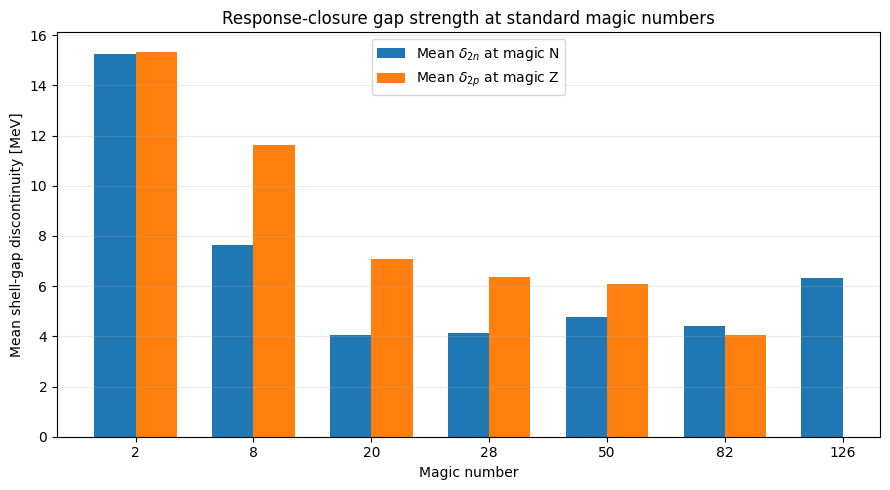

In [14]:
# CELL 13 — FIGURE 5: MAGIC NUMBER SUMMARY BAR CHART

# Build compact bar plot for magic values only
melt_rows=[]
for _, row in magic_summary.iterrows():
    melt_rows.append({'magic_number': int(row['magic_number']), 'channel': 'mean delta2n at magic N', 'gap_MeV': row['delta2n_mean_MeV']})
    melt_rows.append({'magic_number': int(row['magic_number']), 'channel': 'mean delta2p at magic Z', 'gap_MeV': row['delta2p_mean_MeV']})
magic_melt = pd.DataFrame(melt_rows)

fig, ax = plt.subplots(figsize=(9,5))
width = 0.35
x = np.arange(len(MAGIC))
y_n = magic_summary['delta2n_mean_MeV'].values
y_p = magic_summary['delta2p_mean_MeV'].values
ax.bar(x - width/2, y_n, width, label=r'Mean $\delta_{2n}$ at magic N')
ax.bar(x + width/2, y_p, width, label=r'Mean $\delta_{2p}$ at magic Z')
ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in MAGIC])
ax.set_xlabel('Magic number')
ax.set_ylabel('Mean shell-gap discontinuity [MeV]')
ax.set_title('Response-closure gap strength at standard magic numbers')
ax.grid(True, axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG/'fig05_magic_number_gap_summary.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG/'fig05_magic_number_gap_summary.pdf', bbox_inches='tight')
plt.show()


In [16]:
# CELL 14 — EXPORT ZIP FILES AND VERDICT

fig_zip = OUT / 'ecsm_magic_numbers_v1_figures.zip'
tab_zip = OUT / 'ecsm_magic_numbers_v1_tables.zip'

with zipfile.ZipFile(fig_zip, 'w') as z:
    for f in FIG.glob('*'):
        z.write(f, arcname=f.name)

with zipfile.ZipFile(tab_zip, 'w') as z:
    for f in TAB.glob('*'):
        z.write(f, arcname=f.name)

# Verdict metrics
neutron_stats = stats.loc[stats['channel']=='neutron_magic_N_delta2n'].iloc[0].to_dict()
proton_stats = stats.loc[stats['channel']=='proton_magic_Z_delta2p'].iloc[0].to_dict()
closure_N_corr = float(closure_tests.loc[closure_tests['test']=='N exact magic vs delta2n','corr'].iloc[0])
closure_Z_corr = float(closure_tests.loc[closure_tests['test']=='Z exact magic vs delta2p','corr'].iloc[0])

verdict = {
    'notebook': 'ECSM_Magic_Numbers_Response_Closure_V1',
    'data_source': str(AME_CSV_PATH),
    'n_nuclides_used': int(len(work)),
    'magic_numbers_tested': MAGIC,
    'neutron_magic_gap_stats': neutron_stats,
    'proton_magic_gap_stats': proton_stats,
    'closure_descriptor_correlations': {
        'exact_magic_N_vs_delta2n_corr': closure_N_corr,
        'exact_magic_Z_vs_delta2p_corr': closure_Z_corr,
    },
    'qualitative_pass_flags': {
        'magic_N_mean_gap_exceeds_nonmagic': bool(neutron_stats['mean_lift_MeV'] > 0),
        'magic_Z_mean_gap_exceeds_nonmagic': bool(proton_stats['mean_lift_MeV'] > 0),
        'magic_N_median_gap_exceeds_nonmagic': bool(neutron_stats['median_lift_MeV'] > 0),
        'magic_Z_median_gap_exceeds_nonmagic': bool(proton_stats['median_lift_MeV'] > 0),
    },
    'exports': {
        'figure_zip': str(fig_zip),
        'table_zip': str(tab_zip),
        'verdict_json': str(OUT/'magic_numbers_v1_verdict.json'),
    }
}

with open(OUT/'magic_numbers_v1_verdict.json', 'w') as f:
    json.dump(verdict, f, indent=2)

print('='*72)
print('ECSM MAGIC NUMBERS RESPONSE-CLOSURE V1 VERDICT')
print('='*72)
print(json.dumps(verdict, indent=2))
print('Saved:')
print(fig_zip)
print(tab_zip)
print(OUT/'magic_numbers_v1_verdict.json')

ECSM MAGIC NUMBERS RESPONSE-CLOSURE V1 VERDICT
{
  "notebook": "ECSM_Magic_Numbers_Response_Closure_V1",
  "data_source": "/content/drive/MyDrive/ame2020.csv",
  "n_nuclides_used": 3378,
  "magic_numbers_tested": [
    2,
    8,
    20,
    28,
    50,
    82,
    126
  ],
  "neutron_magic_gap_stats": {
    "channel": "neutron_magic_N_delta2n",
    "n_magic": 107,
    "n_nonmagic": 2767,
    "magic_mean_MeV": 5.132886805607509,
    "nonmagic_mean_MeV": 1.2464312890061429,
    "magic_median_MeV": 4.3740777000000435,
    "nonmagic_median_MeV": 0.7629120000003695,
    "mean_lift_MeV": 3.886455516601366,
    "median_lift_MeV": 3.611165699999674,
    "magic_fraction_positive": 1.0,
    "nonmagic_fraction_positive": 0.9884351282977955
  },
  "proton_magic_gap_stats": {
    "channel": "proton_magic_Z_delta2p",
    "n_magic": 130,
    "n_nonmagic": 2537,
    "magic_mean_MeV": 6.327693622615394,
    "nonmagic_mean_MeV": 2.931406160386282,
    "magic_median_MeV": 5.713668699999943,
    "nonmagic

## Interpretation guide

A strong first-pass result would show:

1. Mean and median \(\delta_{2n}\) are larger at magic \(N\) than at non-magic \(N\).
2. Mean and median \(\delta_{2p}\) are larger at magic \(Z\) than at non-magic \(Z\).
3. The standard magic numbers appear among high-ranked mean shell-gap discontinuities.
4. The ECSM magic-closure descriptors correlate positively with observed shell-gap jumps.

If these pass, the paper premise becomes:

> Magic numbers can be interpreted as finite-response closure minima where the nuclear response-cost landscape develops discontinuities in separation-energy gradients.

If the test is weak, the next version should separate stable nuclides, measured-only rows, even-even nuclei, and isotope/isotone chains more carefully.
